# The Power Method: Finding the Dominant Direction by Repetition

**This notebook is self-contained; it recaps eigenvectors before putting them to work.**

There is a startlingly simple way to find the most important eigenvector: pick any vector at all, multiply by $A$ over and over, and watch where it settles. That is the **power method**, and a version of it is how Google originally ranked web pages.

## Learning objectives

- Apply the power method and watch it converge to the **dominant eigenvector**.
- Explain why repeated multiplication amplifies the largest eigenvalue's direction.
- Interpret the dominant eigenvector of a link matrix as a **ranking**.

## Background

Recall an **eigenvector** satisfies $A\mathbf{v} = \lambda\mathbf{v}$ — $A$ scales it without turning it. The **dominant** eigenvector is the one with the largest $|\lambda|$.

Here is why repetition finds it. Any starting vector can be written as a mix of the eigenvectors, $\mathbf{x} = c_1\mathbf{v}_1 + c_2\mathbf{v}_2$. Multiplying by $A$ scales each piece by its own eigenvalue, so after $k$ steps

$$A^k\mathbf{x} = c_1\lambda_1^k\mathbf{v}_1 + c_2\lambda_2^k\mathbf{v}_2.$$

If $|\lambda_1| > |\lambda_2|$ then $\lambda_1^k$ grows faster than $\lambda_2^k$ and the first term takes over — the mix becomes almost pure $\mathbf{v}_1$. Renormalizing at each step to stop the numbers exploding gives the **power method**:

$$\mathbf{x}_{k+1} = \frac{A\mathbf{x}_k}{\lVert A\mathbf{x}_k\rVert}.$$

## This notebook covers

1. Iterating from an arbitrary start; watching the direction settle.
2. Why it works, and how fast — the ratio $|\lambda_2| / |\lambda_1|$.
3. PageRank on a small web graph.

**Prerequisites:** `U2-6_Eigen-1_DirectionsThatDontTurn`

**Dataset:** a small hand-entered link matrix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)

## 1. Multiply, renormalize, repeat

Start from a vector picked with no thought at all and apply $A$ repeatedly, rescaling to length 1 each time so the numbers stay readable. Within a handful of steps the direction stops changing — it has locked onto the dominant eigenvector.

In [2]:
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
helpers.show(A, name="A")

x = np.array([1.0, 0.05])       # an arbitrary starting direction
x = x / np.linalg.norm(x)
helpers.show(np.round(x, 3), label="starting guess")

history = [x.copy()]
print(f"{'step':>4}  {'direction':>22}  {'angle change':>13}")
for k in range(8):
    x_new = A @ x
    x_new = x_new / np.linalg.norm(x_new)
    change = np.degrees(np.arccos(np.clip(np.dot(x, x_new), -1, 1)))
    print(f"{k+1:>4}  [{x_new[0]:8.5f}, {x_new[1]:8.5f}]  {change:>10.4f} deg")
    x = x_new
    history.append(x.copy())

helpers.show(np.round(x, 5), label="where it settled")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

step               direction   angle change
   1  [ 0.88116,  0.47282]     25.3550 deg
   2  [ 0.77429,  0.63283]     11.0420 deg
   3  [ 0.73039,  0.68303]      3.8214 deg
   4  [ 0.71496,  0.69916]      1.2793 deg
   5  [ 0.70973,  0.70447]      0.4266 deg
   6  [ 0.70798,  0.70623]      0.1422 deg
   7  [ 0.70740,  0.70681]      0.0474 deg
   8  [ 0.70720,  0.70701]      0.0158 deg


<IPython.core.display.Math object>

In [3]:
vals, vecs = np.linalg.eig(A)
dominant = vecs[:, np.argmax(np.abs(vals))]
if np.dot(dominant, x) < 0:      # eigenvectors are directions; match the sign for comparison
    dominant = -dominant
helpers.show(np.round(dominant, 5), label="dominant eigenvector from np.linalg.eig")
print(f"largest eigenvalue = {np.max(np.abs(vals)):.3f}")
print("power method agrees?", np.allclose(x, dominant, atol=1e-4))

<IPython.core.display.Math object>

largest eigenvalue = 3.000
power method agrees? True


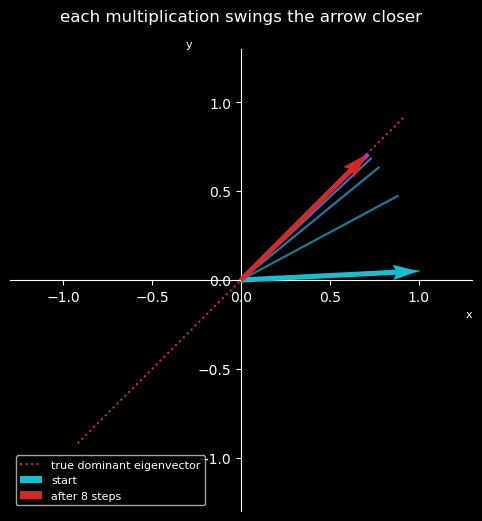

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6))
n = len(history)
for i, v in enumerate(history):
    ax.plot([0, v[0]], [0, v[1]], color=plt.cm.cool(i / (n - 1)), lw=1.6,
            alpha=0.5 + 0.5 * i / (n - 1))
line = np.array([-1.3 * dominant, 1.3 * dominant]).T
ax.plot(line[0], line[1], ":", color="tab:red", lw=1.5, label="true dominant eigenvector")
arrow(ax, (0, 0), history[0], "tab:cyan", "start")
arrow(ax, (0, 0), history[-1], "tab:red", "after 8 steps")

center_axes(ax); label_axes(ax)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8)
ax.set_title("each multiplication swings the arrow closer", pad=20)
plt.show()

## 2. How fast, and why

The convergence rate is set by the ratio $|\lambda_2| / |\lambda_1|$. Each step multiplies the "wrong" component by that ratio, so the error shrinks geometrically:

- ratio near $0$ — the dominant direction crushes the other one, converging in a few steps.
- ratio near $1$ — the two eigenvalues are nearly equal, no direction dominates, and convergence crawls.

Below, three matrices with the same dominant eigenvector but different ratios.

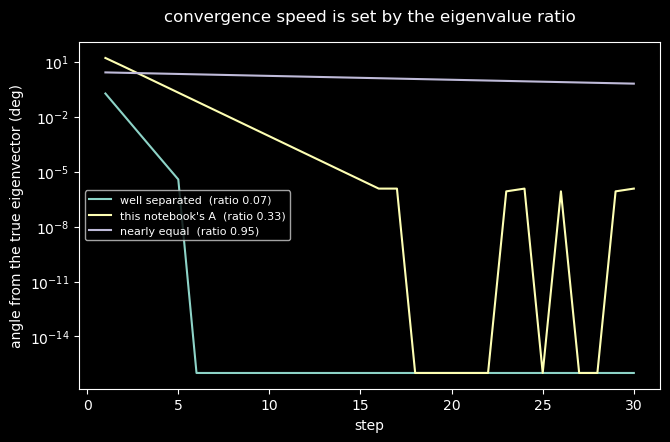

In [5]:
def power_errors(M, steps=30):
    vals, vecs = np.linalg.eig(M)
    true = vecs[:, np.argmax(np.abs(vals))]
    x = np.array([1.0, 0.05]); x /= np.linalg.norm(x)
    errs = []
    for _ in range(steps):
        x = M @ x; x /= np.linalg.norm(x)
        # angle to the true direction (either sign counts, so use |cos|)
        errs.append(np.degrees(np.arccos(np.clip(abs(np.dot(x, true)), -1, 1))))
    return errs, sorted(np.abs(vals))[0] / sorted(np.abs(vals))[1]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for M, name in [(np.array([[3.0, 0.0], [0.0, 0.2]]), "well separated"),
                (np.array([[2.0, 1.0], [1.0, 2.0]]), "this notebook's A"),
                (np.array([[1.05, 0.0], [0.0, 1.0]]), "nearly equal")]:
    errs, ratio = power_errors(M)
    ax.semilogy(range(1, len(errs) + 1), np.maximum(errs, 1e-16),
                label=f"{name}  (ratio {ratio:.2f})")
ax.set_xlabel("step")
ax.set_ylabel("angle from the true eigenvector (deg)")
ax.legend(fontsize=8)
ax.set_title("convergence speed is set by the eigenvalue ratio", pad=15)
plt.show()

## 3. PageRank: ranking a small web

Here is what the power method is actually for. Take four web pages linking to each other. Build a matrix $M$ where $M_{ij} = 1/(\text{number of links out of } j)$ if page $j$ links to page $i$ — so each **column** describes how one page distributes its vote among the pages it links to.

Now imagine a surfer clicking links at random forever. The fraction of time they spend on each page is a vector $\mathbf{r}$ that doesn't change when you take one more click:

$$M\mathbf{r} = \mathbf{r}$$

That is an eigenvector equation with $\lambda = 1$ — and for a matrix like this it is the **dominant** one. So the power method computes it: start anywhere, click around, watch the distribution settle. A page ranks highly when *other highly-ranked pages link to it*, which the repeated multiplication works out on its own.

In [6]:
pages = ["A", "B", "C", "D"]
# who links to whom: links[j] = list of pages that page j points at
links = {"A": ["B", "C"], "B": ["C"], "C": ["A"], "D": ["A", "C"]}

M = np.zeros((4, 4))
for j, src in enumerate(pages):
    outs = links[src]
    for dst in outs:
        M[pages.index(dst), j] = 1 / len(outs)     # column j spreads its vote evenly

helpers.show(M, name="M")
print("each column sums to 1:", np.round(M.sum(axis=0), 3))

<IPython.core.display.Math object>

each column sums to 1: [1. 1. 1. 1.]


In [7]:
r = np.ones(4) / 4                    # start with every page equally important
print(f"{'step':>4}   " + "".join(f"{p:>8}" for p in pages))
print(f"{0:>4}   " + "".join(f"{v:8.4f}" for v in r))
for k in range(12):
    r = M @ r
    r = r / r.sum()                   # keep it a distribution
    if k < 4 or k == 11:
        print(f"{k+1:>4}   " + "".join(f"{v:8.4f}" for v in r))

helpers.show(np.round(r, 4), label="PageRank")
order = np.argsort(-r)
print("\nranking:", "  >  ".join(f"{pages[i]} ({r[i]:.3f})" for i in order))

step          A       B       C       D
   0     0.2500  0.2500  0.2500  0.2500
   1     0.3750  0.1250  0.5000  0.0000
   2     0.5000  0.1875  0.3125  0.0000
   3     0.3125  0.2500  0.4375  0.0000
   4     0.4375  0.1562  0.4062  0.0000
  12     0.4023  0.1973  0.4004  0.0000


<IPython.core.display.Math object>


ranking: A (0.402)  >  C (0.400)  >  B (0.197)  >  D (0.000)


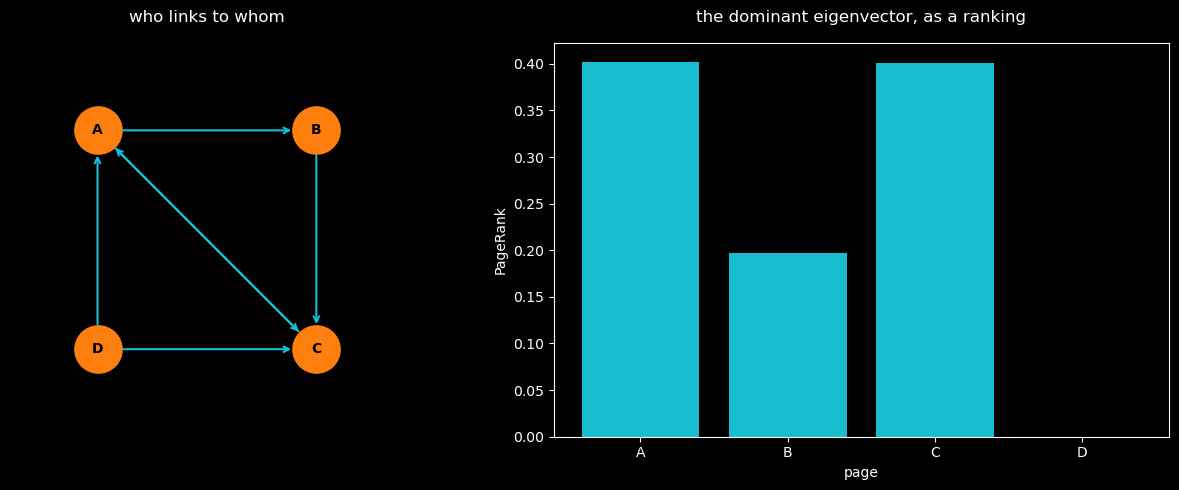

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# the little web, drawn by hand (no networkx dependency)
ax = axes[0]
pos = {"A": (0, 1), "B": (1, 1), "C": (1, 0), "D": (0, 0)}
for src, outs in links.items():
    for dst in outs:
        x0, y0 = pos[src]; x1, y1 = pos[dst]
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="->", color="tab:cyan",
                                    shrinkA=18, shrinkB=18, lw=1.5))
for p, (px, py) in pos.items():
    ax.plot(px, py, "o", color="tab:orange", markersize=34)
    ax.text(px, py, p, ha="center", va="center", color="black", fontweight="bold")
ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.4); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("who links to whom", pad=15)

ax = axes[1]
ax.bar(pages, r, color="tab:cyan")
ax.set_ylabel("PageRank")
ax.set_xlabel("page")
ax.set_title("the dominant eigenvector, as a ranking", pad=15)
plt.tight_layout()
plt.show()

Read the result carefully — it is more interesting than a simple link count.

**A and C tie at the top.** They point at each other, so importance cycles between them and each keeps propping the other up. **B trails** at about half their score: only one page links to it, and that page (A) has to split its vote two ways.

**D scores zero**, even though it links to two pages. PageRank measures *incoming* importance, and nothing links to D. Voting for others earns you nothing.

That last case is a real weakness of the plain method: any page nobody links to gets exactly zero, and a group of pages linking only to each other can hoard importance. Google's actual algorithm patches this with a **damping factor** — the surfer occasionally jumps to a random page instead of clicking a link, so every page gets a small baseline score. The eigenvector idea is unchanged; only the matrix is adjusted.

The key point stands: the ranking is **not** a count of incoming links. It weights each link by how important the *linking* page is — a recursive definition, which is exactly what $M\mathbf{r} = \mathbf{r}$ encodes.

## 4. Summary

- The **power method** — multiply by $A$, renormalize, repeat — converges to the **dominant eigenvector** from almost any start.
- It works because each multiplication scales every eigen-component by its own $\lambda$, so the largest one takes over.
- Convergence speed is governed by $|\lambda_2| / |\lambda_1|$; near-equal eigenvalues converge slowly.
- **PageRank** is the dominant eigenvector of a link matrix: importance defined recursively, computed by repetition.

Next: the capstone. A covariance matrix is symmetric, so its eigenvectors are perpendicular — and those eigenvectors are the **principal components** (`U2-7_PCA-1_Intuition`).